In [ ]:
# imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch

from sklearn.neighbors import NearestNeighbors
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    "font.family": "serif",
    'mathtext.fontset': 'dejavuserif'
})

In [ ]:
def generate_spiral_data(num_samples: int):
    N = num_samples // 2

    theta = np.sqrt(np.random.rand(N))*4*np.pi

    r_a = 4*theta + np.pi
    data_a = np.array([np.cos(theta)*r_a, np.sin(theta)*r_a]).T
    x_a = data_a + np.random.randn(N,2) * 3
    label_a = np.array([0]*N)[:, None]


    r_b = -4*theta - np.pi
    data_b = np.array([np.cos(theta)*r_b, np.sin(theta)*r_b]).T
    x_b = data_b + np.random.randn(N,2) * 3
    label_b = np.array([1]*N)[:, None]

    x = np.concatenate([x_a, x_b], axis=0)
    x /= np.std(x, axis=0)
    y = np.concatenate([label_a, label_b], axis=0)
    return x*10 + 8, y.squeeze()

## Zadanie 0. Wygeneruj zbiór danych

In [ ]:
np.random.seed(42)

days = 100
data = {
    'Date': pd.date_range(start='2023-01-01', periods=days),
    'Temperature_C': np.random.uniform(-5, 35, days),
    'Sunlight_Hours': np.random.uniform(0, 14, days),
}

production = data['Sunlight_Hours'] * (data['Temperature_C'] + 20) * 0.5 + np.random.normal(0, 5, days)
data['Energy_Production_kWh'] = np.maximum(production, 0)

df_gen = pd.DataFrame(data)
df_gen.to_csv('solar_energy.csv', index=False)

print("File 'solar_energy.csv' has been generated.")

File 'solar_energy.csv' has been generated.


## Zadanie 1. Pandas - ładowanie danych + wstępna analiza

Załaduj `solar_energy.csv` korzystając z funkcji pandasowej.

Wyświetl podstawowe statystyki danych korzystając z funkcji `describe`.

Stwórz nowy DataFrame `df_sunny`, który ma tylko takie dane, gdzie `Sunlight_Hours` są większe niż średnia produkcja w całym datasecie.

Wyświetl pierwsze 3 rzędy `df_sunny`


## Zadanie 2. Numpy - reshaping i mnożenie macierzowe

Pamiętaj aby w tym zadaniu nie używać żadnych pętli. Należy korzystać z operacji wektorowych.

Chcemy obliczyć teoretyczny potencjał korzystając z następującej formuły:

```
potential = w1 * temperature + w2 * sunlight + bias
```

1. Wyciągnij dane `Temperature_C` oraz `Sunlight_Hours` z DataFrame i przekonwertuj je na ndarray.

2. Zreshapuj je tak aby z shape `(100,)` zrobić shape `(100, 1)`.

3. Skonkatenuj je horyzontalnie tak aby uzyskać macierz X o kształcie `(100, 2)`.

4. Stwórz macierz wag W o kształcie `(2, 1)` i wartościach `[[0.5], [2.0]]`.

5. Wykonaj mnożenie macierzowe dwóch macierzy

6. Dodaj bias, np o wartości 10.

7. Wyprintuj finalny shape wyniku

Original shape: (100,)
Reshaped shape: (100, 1)
Feature Matrix X shape: (100, 2)
Final Output shape: (100, 1)
First 5 values:
 [[15.87081958]
 [44.33377764]
 [30.94184631]
 [33.71314904]
 [36.03223408]]


## Zadanie 3. Matplotlib - wizualizacja

Zwizualizuj wyniki z poprzedniego zadania oraz te z CSV.

1. Stwórz scatter plot
2. Wyplotuj `Energy_Production_kWh` (te prawdziwą wartość z csv) jako niebieską linie albo kropki
3. Wyplotuj `theoretical_potential` obliczony w poprzednim zadaniu jako czerwoną linię lub kropki.
4. Dodaj legendę i opisz osie X i Y

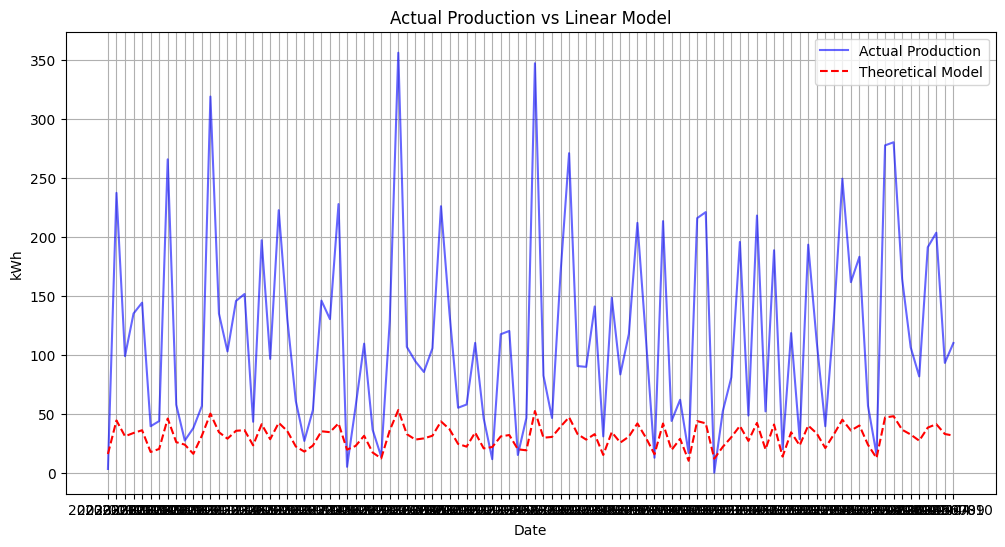

## Zadanie 4. Pytorch - manipulacja tensorami.

W deep learningu często modele pracują na 3D lub 4D tensorach (np. `[batch_size, sequence_lenght, features]`).

1. Skonwertuj macierz X z zadania 2 do Tensora. Upewnij się, że `dtype=float32`.

2. Dodaj dodatkowy wymiar do otrzymanej macierzy, który będzie symulował batch. Shape ma wyglądać następująco `[1, 100, 2]`.

3. Udawajmy, że chcemy to podać do RNNa, który analizuje sekwencje 10dniowe. Musisz zatem zreshapować otrzymany tensor do wymiaru `[10, 10, 2]`.

Base Tensor shape: torch.Size([100, 2])
Unsqueezed shape: torch.Size([1, 100, 2])
RNN Input shape: torch.Size([10, 10, 2])

First sequence in the batch (first 2 days):
tensor([[ 9.9816,  0.4400],
        [33.0286,  8.9097]])


## Zadanie 5: NumPy i Wektoryzacja
W uczeniu maszynowym operujemy na ogromnych macierzach danych. Używanie standardowych pętli `for` w Pythonie drastycznie spowalnia obliczenia. Waszym zadaniem jest napisanie funkcji obliczającej odległość euklidesową między punktami, wykorzystując mechanizm **broadcasting'u** w NumPy. Nie możecie użyć ani jednej pętli `for`!

In [ ]:
import numpy as np

# Generate a dataset of 100 random points in 2D space
A = np.random.rand(100, 2)
# Define a single target point
B = np.array([[0.5, 0.5]])

def find_closest_vectorized(A, B):
    """
    Calculates the Euclidean distance from target_point to all points in points_matrix.
    Returns the index of the closest point. No 'for' loops allowed!
    """
    # TODO: Your code here
    pass

closest_index = find_closest_vectorized(A, B)
print(f"Index of the closest point: {closest_index}")
print(f"Coordinates of the closest point: {A[closest_index]}")

## Zadanie 6: Pandas i Czyszczenie Danych
Zanim dane trafią do sieci neuronowej, muszą zostać oczyszczone (tzw. preprocessing). Poniżej znajduje się słownik z logami z treningu różnych modeli. Zamień go na DataFrame, usuń wiersze z brakującą wartością funkcji straty (`loss`), a następnie oblicz średni czas treningu dla każdej z architektur.


In [ ]:
data_logs = {
    'model_id': [1, 2, 3, 4, 5, 6],
    'model_type': ['CNN', 'Transformer', 'CNN', 'Transformer', 'MLP', 'MLP'],
    'loss': [0.45, np.nan, 0.22, 0.11, 0.85, np.nan],
    'training_time_s': [120, 450, 110, 500, 45, 50]
}

'''
 1. Convert the dictionary to a pandas DataFrame
 2. Drop rows where ONLY the 'loss' column has a NaN value
 3. Group by model type and calculate the mean of training time
 4. Display the results
'''

# TODO: Your code here

## Zadanie 7: Matplotlib i Krzywa Uczenia (Loss Curve)
Podstawowym narzędziem do diagnozowania modeli AI jest wykres funkcji straty. Waszym zadaniem jest zasymulowanie spadku błędu modelu na przestrzeni 50 epok i narysowanie czytelnego wykresu. Dodajcie również poziomą linię oznaczającą próg akceptacji błędu.


In [ ]:
'''
1. Generate epochs (1 to 50)
2. Simulate training loss (exponential decay) and add some random noise
3. Plot the main loss curve
4. Add a horizontal dashed line for the acceptable loss threshold (e.g., y=0.1)
5. Add aesthetic elements: title, labels, and legend
'''
# TODO: Your code here

## Zadanie 8: PyTorch, Autograd i Akceleracja GPU
Zrozumienie, jak działają tensory i automatyczne różniczkowanie (`autograd`), to fundament pracy z PyTorchem i algorytmem wstecznej propagacji błędu (backpropagation). Zbudujcie prosty graf obliczeniowy, policzcie gradient względem wagi modelu i sprawdźcie, czy środowisko obsługuje sprzętową akcelerację (GPU).


In [ ]:
'''
1. Define input scalar 'x'
2. Define weight scalar 'w'.
3. Perform a mathematical operation (forward pass)
Equation: y = w * (x^2) + 5
4. Perform backpropagation (compute derivatives)
5. Print the gradient of y with respect to w (dy/dw)
6. Check for GPU availability (CUDA for NVIDIA, MPS for Apple Silicon) and move a tensor there
7. Create a random 100x100 tensor and send it to the selected device
'''
# TODO: Your code here

## Zadanie 9 - NumPy

Wykorzystując bibliotekę NumPy, utwórz macierz o wymiarach 8x8, wypełnioną zerami i jedynkami układającymi się naprzemiennie we wzór szachownicy. Zadanie rozwiąż w maksymalnie trzech linijkach kodu. Nie używaj pętli.

## Zadanie 10 - Pandas

Wykorzystując biblioteki NumPy i Pandas, utwórz obiekt DataFrame składający się z dokładnie 100 obserwacji, reprezentujący dowolną, wybraną przez Ciebie dziedzinę. Wymagane jest wygenerowanie:

- Minimum dwóch kolumn numerycznych opartych na dowolnym ciągłym rozkładzie (stanowiących zmienne objaśniające/cechy).

- Jednej kolumny kategorycznej zawierającej losowo przypisane wartości z zamkniętej puli (minimum 3 elementy).

- Zmiennej docelowej, która jest zdefiniowana jako funkcja matematyczna oparta na wygenerowanych wcześniej cechach numerycznych, do której należy dodać losowy szum (np. z rozkładu normalnego), aby zasymulować realistyczne dane.

Unikaj iteracyjnego dodawania wierszy lub kolumn. Wypisz wybrane statystyki zbioru.

Przykład: X = [moc silnika, wiek auta, marka], y = [cena]

## Zadanie 11 - Scikit-learn

Wykorzystując syntetyczny zbiór danych wygenerowany w poprzednim kroku, przygotuj zmienne objaśniające ($X$) oraz zmienną docelową ($y$). Pamiętaj o konieczności przekształcenia kolumny kategorycznej do postaci numerycznej odpowiedniej dla modeli liniowych - rozważ różne metody.
Podziel zbiór na część treningową i testową (w proporcji 80/20).
Wytrenuj prosty model regresji.
Oblicz i wypisz na ekranie wartość błędu średniokwadratowego (MSE) zarówno dla zbioru treningowego, jak i testowego.

## Zadanie 12 - PyTorch

Wykorzystując bibliotekę PyTorch, zdefiniuj jednowymiarowy tensor $x$. Następnie zdefiniuj funkcję kwadratową $y$. Uruchom propagację wsteczną i wypisz na ekranie obliczoną wartość pochodnej funkcji $y$ po zmiennej $x$.

## Zadanie 13

- Use `x, y = generate_spiral_data(NUM_SAMPLES)` to generate a `2D` dataset of `500` samples, where `x` represents samples and `y` corresponding labels.  

- Write a function in matplotlib that visualizes those samples (Use `scatter` to plot samples, and use `y` as color labels)

- What do you notice about data range?

## Zadanie 14

using `numpy`, check mean and std of the dataset, then normalize to mean=0, std=1 and visualize again.

## Zadanie 15

Using numpy, Write a function that generates a 2D grid of coordinates covering the min-max range of a given dataset. \


```
def generate_2d_grid(x_train: np.ndarray, res: int) -> np.ndarray:
```


- use `min` and `max` operations to determine ranges on first and second coordinate
- use `linspace` to generate axis for both coordinates with `res` variable as step
- use `meshgrid` to convert axis to grids
- stack and reshape results to a shape `(res*res, 2)`

## Zadanie 16

For different values of $K \in {1, ..., 10}$
train `KNeighborsClassifier` model on `x` and `y`, then visualize its geometry with matplotlib by predicting the `grid`.

- Import `KNeighborsClassifier`
- Fit to `x` and `y`
- predict `grid` from previous task
- reshape prediction to (`res`, `res`) and visualize with `imshow`
- repeat for different values of `K`